# Running steps manually & add-hoc operations

In [1]:
import matplotlib.pyplot as plt
import os

import pyopia.classify
import pyopia.process
import pyopia.statistics
import pyopia.pipeline
import pyopia.instrument.silcam
import pyopia.io
import pyopia.exampledata
import pyopia.plotting

## Installation note:

These examples use 'classification' optional dependencies, which you should have installed (see [here](https://pyopia.readthedocs.io/en/latest/intro.html#installing)). 

#### Initial admin

In [2]:
# get an image and filename for working on in this example
filename = pyopia.exampledata.get_example_silc_image(os.getcwd())

# Initial start of the settings, which will be added to as we go
settings = {'general': {'raw_files': None,
                        'pixel_size': 24},
            'steps': {'note': 'non-standard pipeline.'}
           }

# Initialise the pipeline class without running anything
MyPipeline = pyopia.pipeline.Pipeline(settings=settings, initial_steps='')

Example image already exists. Skipping download.
Initialising pipeline


#### Setup classification

This is the first pipeline step top run.
We will first define in the settings dictionary (as we would normally do in the toml file).
Then we execute the step using Pipeline.run_step().

We could call the method directly and skip the settings definitions, but by first defining the setup within the settings['steps'], we ensure that the metadata description of the pipeline matches what we have actually done.

In [3]:
# Get the example trained model
model_path = pyopia.exampledata.get_example_model(os.getcwd())

# Add the classifier step description to settings (i.e. metadata)
MyPipeline.settings['steps'].update({'classifier':
                                       {'pipeline_class': 'pyopia.classify.Classify',
                                       'model_path': model_path}
                                    })

# Execute the classifier step we defined above
MyPipeline.run_step('classifier')
# This is the same as running:
# MyPipeline.data['cl'] = pyopia.classify.Classify(model_path=model_path)
# Note: the classifier step is special in that it's output is specifically data['cl'], rather than other new keys in data

MyPipeline.data

Classify  ready with: {'model_path': 'keras_model.h5'}  and data dict_keys(['cl', 'settings', 'raw_files'])


{'cl': <pyopia.classify.Classify at 0x1057183d0>,
 'settings': {'general': {'raw_files': None, 'pixel_size': 24},
  'steps': {'note': 'non-standard pipeline.',
   'classifier': {'pipeline_class': 'pyopia.classify.Classify',
    'model_path': 'keras_model.h5'}}},
 'raw_files': None}

#### Load an image

SilCamLoad  ready with: {}  and data dict_keys(['cl', 'settings', 'raw_files', 'filename'])


Text(0.5, 1.0, 'imraw')

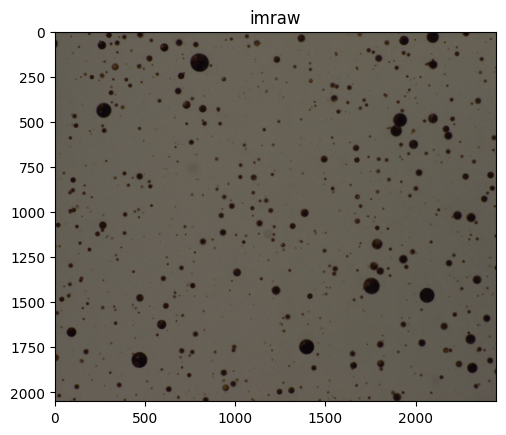

In [4]:
# Since we are not going to be using MyPipeline.run(filename) here, we need to manually add filename into the pipeline data:
MyPipeline.data['filename'] = filename

# Add the load step description
MyPipeline.settings['steps'].update({'load':
                                       {'pipeline_class': 'pyopia.instrument.silcam.SilCamLoad'}
                                    })

# Run the step
MyPipeline.run_step('load')
# This is the same as running:
# SilCamLoad = pyopia.instrument.silcam.SilCamLoad()
# MyPipeline.data = SilCamLoad(MyPipeline.data)

plt.imshow(MyPipeline.data['imraw'][:,:,:]/255)
plt.title('imraw')

#### Image preparation

In [ ]:
# Add the imageprep step description
MyPipeline.settings['steps'].update({'imageprep':
                                       {'pipeline_class': 'pyopia.instrument.silcam.ImagePrep',
                                        'image_level': 'imraw'}
                                    })
# Run the step
MyPipeline.run_step('imageprep')
# This is the same as running:
# ImagePrep = pyopia.instrument.silcam.ImagePrep(image_level='imraw')
# MyPipeline.data = ImagePrep(MyPipeline.data)

plt.imshow(MyPipeline.data['im_minimum'], cmap='grey')
plt.title('im_minimum')

#### Segmentation

In [ ]:
# Add the segmentation step description
MyPipeline.settings['steps'].update({'segmentation':
                            {'pipeline_class': 'pyopia.process.Segment',
                            'threshold': 0.85,
                            'segment_source': 'im_minimum'}}
                        )
# Run the step
MyPipeline.run_step('segmentation')
# This is the same as running:
# Segment = pyopia.process.Segment(threshold=settings['steps']['segmentation']['threshold'])
# data = Segment(data)

plt.imshow(~MyPipeline.data['imbw'], cmap='grey')
plt.title('imbw')

#### Insert an add-hoc step

Let's write some custom code that is used as an add-hoc step in the middle of a pipeline.

Here we will add a 1-pixel dilation around all particles using skimage. We will still describe the step in the settings (metadata), so it is recorded together with the data

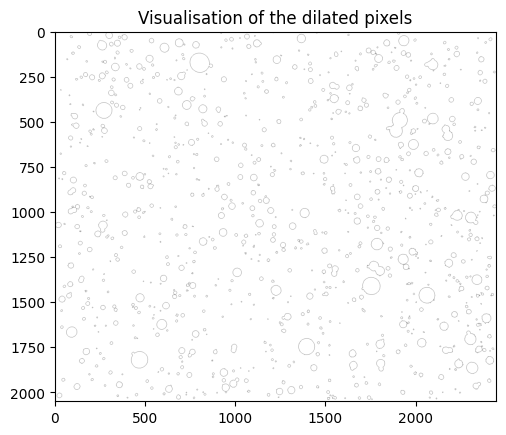

In [7]:
# Define a step for inserting into the metadata.
MyPipeline.settings['steps'].update(
                    {'dilation':
                        {'custom step': 'dilate segmented image by 1 pixel'}}
                )

# run our custom code
import skimage

imbw_original = MyPipeline.data['imbw']
imbw_dilated = skimage.morphology.binary_dilation(imbw_original)

plt.imshow(imbw_original.astype(int) - imbw_dilated.astype(int), cmap='grey')
plt.title('Visualisation of the dilated pixels')

# redefine 'imbw', which is needed for the next step
MyPipeline.data['imbw'] = imbw_dilated

In [ ]:
# Add the segmentation step description
MyPipeline.settings['steps'].update({'statextract':
                                        {'pipeline_class': 'pyopia.process.CalculateStats',
                                        'roi_source': 'imref'}}
                                    )

# Run the step
MyPipeline.run_step('statextract')
# This is the same as running:
# CalculateStats = pyopia.process.CalculateStats()
# data = CalculateStats(data)


#### Output data

Make an xarray of the processed data and metadata, which is conforming to the output PyOPIA gives from running a pipeline

In [9]:
xstats = pyopia.io.make_xstats(MyPipeline.data['stats'], settings)
xstats

<xarray.Dataset>
Dimensions:                     (index: 853)
Coordinates:
  * index                       (index) int64 0 1 2 3 4 ... 848 849 850 851 852
    time                        (index) datetime64[ns] 2018-11-01T14:27:31.83...
Data variables: (12/17)
    major_axis_length           (index) float64 7.811 17.56 23.1 ... 8.056 7.524
    minor_axis_length           (index) float64 4.533 14.91 ... 6.461 4.763
    equivalent_diameter         (index) float64 5.863 16.12 ... 7.225 5.971
    minr                        (index) float64 2.0 2.0 ... 2.032e+03 2.036e+03
    minc                        (index) float64 76.0 1.895e+03 ... 1.753e+03
    maxr                        (index) float64 9.0 19.0 ... 2.04e+03 2.044e+03
    ...                          ...
    probability_copepod         (index) float64 0.004393 2.323e-06 ... 0.002888
    probability_diatom_chain    (index) float64 0.003636 2.031e-07 ... 0.003968
    probability_oily_gas        (index) float64 0.06183 0.008561 ... 0.03824
    export name                 (index) object 'D20181101T142731.838206-PN0' ...
    timestamp                   (index) datetime64[ns] 2018-11-01T14:27:31.83...
    saturation                  (index) float64 24.77 24.77 ... 24.77 24.77
Attributes:
    steps:           [general]\npixel_size = 24\n\n[steps]\nnote = "non-stand...
    Modified:        2024-08-09 13:10:53.817878
    PyOpia version:  1.1.4